In [1]:
%load_ext autoreload
%autoreload 2
def loadDfs():
  dfs_to_load = [
    "~/OneDrive/Mouse2AFC_live/report/aggregates/all_Rbp4_M2.dump",
    "~/OneDrive/Mouse2AFC_live/report/aggregates/all_vgat.dump",
    "~/OneDrive/Mouse2AFC_live/report/aggregates/all_animals_oeig.pkl"
  ]
  import pandas as pd
  dfs = []
  for fp in dfs_to_load:
    dfs.append(pd.read_pickle(fp))
  return pd.concat(dfs)

def setup():
  import os
  from pathlib import Path
  #print(os.path.dirname(os.getcwd()))
  cur_dir = Path(os.getcwd())
  if cur_dir.name == "report":
    os.chdir(cur_dir.parent)
    print("Changing directories")
  from report import analysis
  analysis.setMatplotlibParams(silent=True)
setup()
raw_df = loadDfs()

Changing directories


Fonud: vgat2.5 - Num trials: 3,884
Bad performance (66.10%) for 2021-01-12-Sess1 - Len: 124
Bad performance (74.68%) for 2021-01-14-Sess1 - Len: 179
Insufficient trials (16) for 2021-01-20-Sess1
Insufficient trials (27) for 2021-01-25-Sess2
Reaction time len: 3016 - MinSamplingMax dist: 5.0    2594
2.0     429
Name: GUI_MinSampleMax, dtype: int64


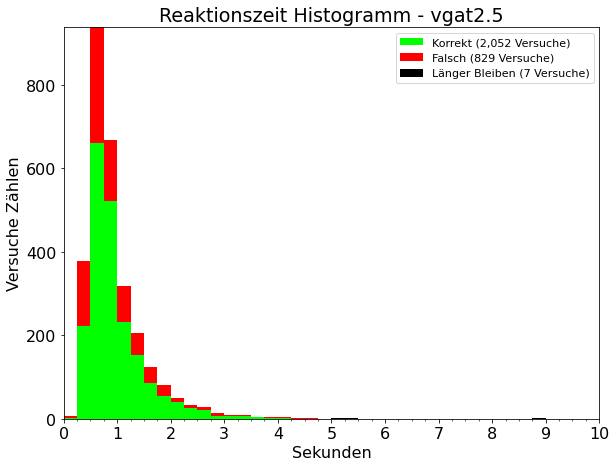

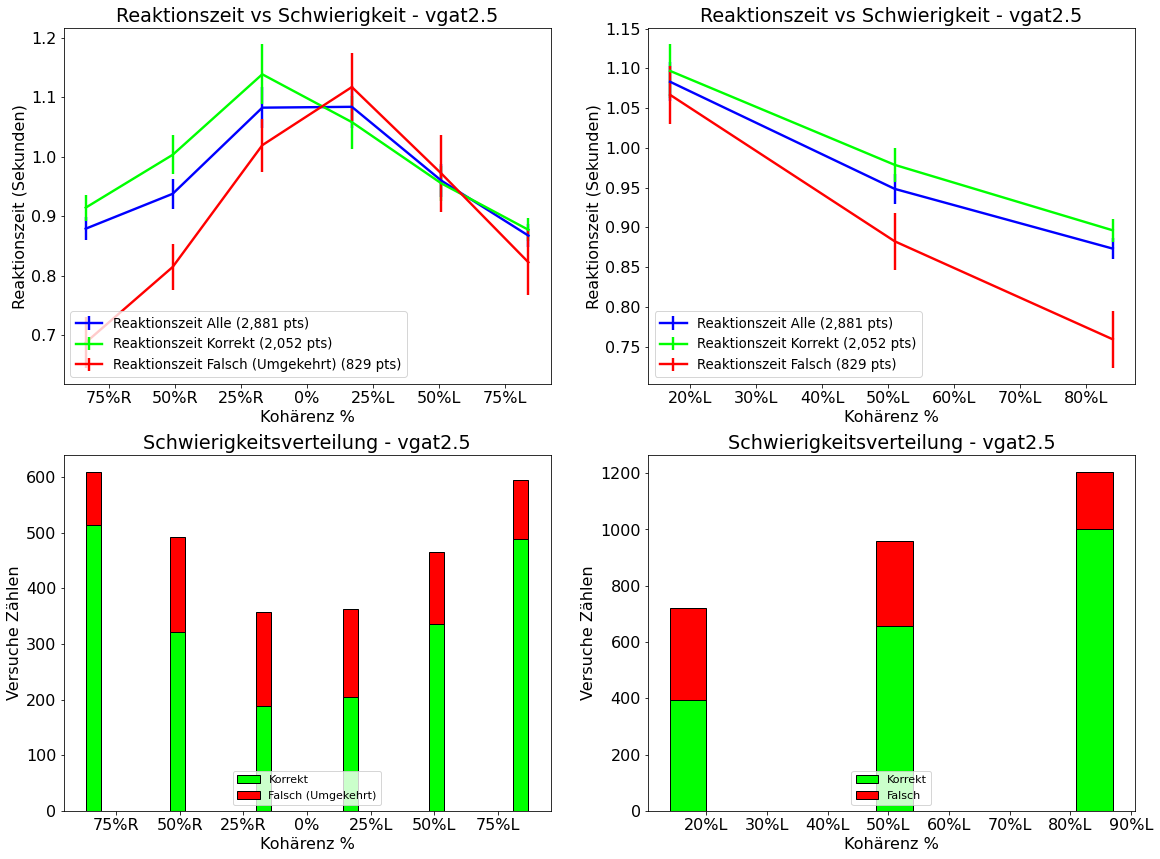

In [29]:
def run(df):
  from os.path import expanduser
  home = expanduser("~")
  from report.evdaccum.reactiontime import reactionTime, Plots, AllPlots, NoPlots
  from report.evdaccum.evdutils import Kargs, GroupBy
  from report.definitions import ExpType

  short_long_quantile = None
  vs_diff_kargs = Kargs(quantile_top_bottom=None, save_figs=False,
                        exp_type=ExpType.RDK, grpby=GroupBy.Difficulty,
                        plot_only_all=False, periods=3,
                          #save_prefix="proto/x_VsDiff/")
                        save_prefix=home+r"/OneDrive/Documents/py_matlab/analysis_run/proto/ReactionTimeShadlen/")
  import datetime as dt
  # raw_df[(raw_df.Date != dt.date(2021,1,8)) & (raw_df.calcReactionTime < 2)]
  # AllPlots & ~Plots.MinSampleDistHist
  # Plots.ReactionTimeVsDiff
  # Plots.ReactionTimeVsDiff | Plots.ReactionTimeVsDiffHist,
  df = df[df.Name == "vgat2.5"]
  plots = Plots.ReactionTimeVsDiff | Plots.ReactionTimeVsDiffHist | Plots.ReactionTimeDistHist
  reactionTime(df, overall_plots=plots,
               sess_plots=NoPlots, min_easiest_perf=75, cut_below_trial_num=30,
               short_long_quantile=short_long_quantile, dv_bins_edges=[],#[0.3, 0.6],
               min_total_num_pts_per_animal=400, **vs_diff_kargs)
run(raw_df)

In [22]:
FILENAME=r"C:\Users\hatem\Downloads\Chronometry-Hatem.csv"
with open(FILENAME, 'r') as f:
  # FILENAME.rsplit("\\", 1)[-1]
  uploaded = {FILENAME: f.read()}
# print("Uploaded:", uploaded_dict)

In [23]:
import matplotlib.pyplot as plt
import datetime as dt
from report import analysis

def loadFiles(uploaded_dict):
  analysis.setMatplotlibParams(silent=True)
  filenames = list(uploaded_dict.keys())
  if len(filenames) != 1:
    display("Please upload only one file.")
    display("Please run this cell again and upload a single file.")
    return
  import pandas as pd
  res = pd.read_csv(filenames[0])
  res = res[res.TrialNumber.notnull()]
  res["ChoiceLeft"] = (res["key_press"] == 37).astype(float)
  res["ChoiceCorrect"] = res["correct"].astype(float)
  res["MaxTrial"] = res.TrialNumber.max()
  res["calcReactionTime"] = 0# "PLACEHOLDER"
  res["TrialStartTimestamp"] = res["time_elapsed"]/1000.0 # Convert to seconds
  res["LeftRewarded"] = (res["Direction"] == "Left").astype(int)
  res["ST"] = res["rt"]/1000#res["trial_duration"]
  res.loc[res["ST"] == -1, "ST"] = res[res["ST"] == -1].rt
  res["Name"] = "Reaction Time"
  res["Date"] = dt.date.today()
  res["TrialNumber"] = res["TrialNumber"].astype(int)
  res["SessionNum"] = 1
  res["ForcedLEDTrial"] = False
  dv_dir = res["LeftRewarded"].replace(0, -1)
  res["DV"] = res["coherence"] * dv_dir
  #print("Res:")
  #imp_cols = ["rt", "coherence", "time_elapsed", "correct", "trial_duration", "frame_rate", "TrialNumber", "Difficulty", "Direction", "ChoiceLeft"]
  imp_cols = ["TrialNumber", "DV", "ChoiceCorrect", "ChoiceLeft", "LeftRewarded",
              "Direction", "ST", "calcReactionTime", "TrialStartTimestamp",
              "frame_rate", "MaxTrial", "Difficulty", "Name",
               "ForcedLEDTrial", "Date", "SessionNum",]
  res = res[imp_cols].reset_index(drop=True)
  #new_cols = ["calcReactionTime", "coherence", "time_elapsed", "correct", "trial_duration", "frame_rate", "TrialNumber", "Difficulty", "Direction"]
  #display(res)
  return res

user_df = loadFiles(uploaded)

In [31]:
#@title Run this cell - Press the play button on this cell
#%%capture
#!(rm -rf Mouse2AFC || true) && (rm -rf report || true) && git clone --depth 1 --recurse-submodules --shallow-submodules --single-branch -b larkum_lab https://github.com/marionbosc/Mouse2AFC.git 2>&1 > git_out && mv Mouse2AFC/report . && rm -rf Mouse2AFC/
#%load_ext autoreload
#%autoreload 2
from report import analysis


import matplotlib.pyplot as plt
import datetime as dt
from report import analysis

def loadFiles(uploaded_dict):
  analysis.setMatplotlibParams(silent=True)
  filenames = list(uploaded_dict.keys())
  if len(filenames) != 1:
    display("Please upload only one file.")
    display("Please run this cell again and upload a single file.")
    return
  import pandas as pd
  res = pd.read_csv(filenames[0])
  res = res[res.TrialNumber.notnull()]
  is_chrono = res.Experiment.unique()[0] == "Chronometry"
  name = 'Chronometry' if is_chrono else 'Reaction-Time'
  print(f"Loading {name} data...")
  if is_chrono:
    choices = res[res.trial_type == "html-keyboard-response"].key_press
    rt = res[res.trial_type == "html-keyboard-response"].rt
    res = res[res.trial_type == "rdk"]
    res.loc[res.trial_type == "rdk", "key_press"] = choices.values
    res.loc[res.trial_type == "rdk", "rt"] = rt.values
    res["correct"] = False
    res.loc[((res.Direction == "Left") & (res.key_press == 37) |
             (res.Direction == "Right") & (res.key_press == 39)), "correct"] = True
  res["ChoiceLeft"] = (res["key_press"] == 37).astype(float)
  res["ChoiceCorrect"] = res["correct"].astype(float)
  res["MaxTrial"] = res.TrialNumber.max()
  res["calcReactionTime"] = res.trial_duration/1000 if is_chrono else 0
  res["TrialStartTimestamp"] = res["time_elapsed"]/1000.0 # Convert to seconds
  res["LeftRewarded"] = (res["Direction"] == "Left").astype(int)
  res["ST"] = res["rt"]/1000#res["trial_duration"]
  res.loc[res["ST"] == -1, "ST"] = res[res["ST"] == -1].rt
  res["MinSample"] = res["trial_duration"]/1000 if is_chrono else 0.1
  res["Name"] = name
  res["Date"] = dt.date.today()
  res["TrialNumber"] = res["TrialNumber"].astype(int)
  res["SessionNum"] = 1
  res["ForcedLEDTrial"] = False
  dv_dir = res["LeftRewarded"].replace(0, -1)
  res["DV"] = res["coherence"] * dv_dir
  #print("Res:")
  #imp_cols = ["rt", "coherence", "time_elapsed", "correct", "trial_duration", "frame_rate", "TrialNumber", "Difficulty", "Direction", "ChoiceLeft"]
  imp_cols = ["TrialNumber", "DV", "ChoiceCorrect", "ChoiceLeft", "LeftRewarded",
              "Direction", "MinSample", "ST", "calcReactionTime", "TrialStartTimestamp",
              "frame_rate", "MaxTrial", "Difficulty", "Name",
               "ForcedLEDTrial", "Date", "SessionNum",]
  res = res[imp_cols].reset_index(drop=True)
  #new_cols = ["calcReactionTime", "coherence", "time_elapsed", "correct", "trial_duration", "frame_rate", "TrialNumber", "Difficulty", "Direction"]
  #display(res)
  return res

def rt(df):
  analysis.setMatplotlibParams(silent=True)
  df["GUI_StimAfterPokeOut"] = False
  df["GUI_MouseState"] = 2
  df["GUI_RewardAfterMinSampling"] = False
  df["CenterPortRewAmount"] = 0
  df["MinSample"] = 0.1
  df["GUI_MinSampleMax"] = 0.1
  df["GUI_StimulusTime"] = 5 # Seconds, otherwise overstay
  df["Difficulty1"] = df.DV.abs() * 100
  df["Difficulty3"] = 0
  from report.definitions import ExpType
  df["GUI_ExperimentType"] = ExpType.RDK
  #print(df.ST)
  # print(df.calcReactionTime)
  from report.evdaccum.reactiontime import reactionTime, Plots, NoPlots
  from report.evdaccum.evdutils import Kargs, GroupBy
  short_long_quantile = 0.3
  vs_diff_kargs = Kargs(quantile_top_bottom=None, save_figs=False,
                        exp_type=ExpType.RDK, grpby=GroupBy.EqualSize,
                        plot_only_all=False,
                        #save_prefix="proto/x_VsDiff/")
                        save_prefix="proto/ReactionTimeShadlen/")
  reactionTime(df, 
               overall_plots=Plots.ReactionTimeVsDiff | Plots.ReactionTimeVsDiffHist | Plots.ReactionTimeDistHist, 
               sess_plots=NoPlots, min_easiest_perf=75, periods=3,
               cut_below_trial_num=0, short_long_quantile=short_long_quantile,
               **vs_diff_kargs)


def psych(df):
  analysis.setMatplotlibParams(silent=True)
  ax = analysis.psychAxes("Reaktionszeit")
  ax.set_title(f"Psychometrie - {Experiment}")
  ax.set_ylabel("Linkspfeil Gedrückt")
  ax.set_xlabel("Kohärenz")
  analysis.psychAnimalSessions(df, "Reaktionszeit", ax, analysis.METHOD,
                               periods=10, fitkargs={"nfits":50})
  #analysis.savePlot("./Mostafa_reaction_time_psych")
  plt.show()

def trialRate(df):
  axes = plt.axes()
  analysis.trialRate(df, ax=axes, max_sess_time_lim_bug=24*60*60, # sec to hour
                     num_days_per_clr=10, IQR_filter=False)
  plt.show()

# RDK_WT1_Mouse2AFC_Dec04_2019_Session1.mat

In [51]:
def run(df):
  from report.evdaccum.decisiontime import decisionTime, Plots, AllPlots, NoPlots
  from report.evdaccum.evdutils import Kargs, GroupBy
  from report.definitions import ExpType
  short_long_quantile = 0.3
  vs_diff_kargs = Kargs(quantile_top_bottom=None, save_figs=False,
                        exp_type=ExpType.RDK, grpby=GroupBy.Difficulty,
                        plot_only_all=False, periods=3,
                          #save_prefix="proto/x_VsDiff/")
                        save_prefix="proto/DecisionTime/")
  import datetime as dt
  # raw_df[(raw_df.Date != dt.date(2021,1,8)) & (raw_df.calcReactionTime < 2)]
  # AllPlots & ~Plots.MinSampleDistHist
  # Plots.ReactionTimeVsDiff
  decisionTime(raw_df, animal_plots=Plots.DecisionTimeVsDiff | Plots.DecisionTimeVsDiffHist | Plots.EWDVsDiff | Plots.EWDVsDiffHist, #Plots.ReactionTimeDistHist,
               sess_plots=NoPlots, all_animals_plots=NoPlots, min_easiest_perf=75, cut_below_trial_num=30,
               short_long_quantile=short_long_quantile, **vs_diff_kargs)
run(raw_df)

Bad performance (38.46%) for 2019-12-12-Sess1 - Len: 79
Bad performance (52.94%) for 2019-12-16-Sess1 - Len: 98
Subjext: RDK_WT1 - Chrone data max trial: [390 275 507 713 579 502 434 399 429 443 499 389 366 364 385 407 289 447
 505 483 433 313 321 400 386 537 560 365]
Min sampling points: [0.3, 0.6, 0.8999999999999999, 1.0, 1.2]
α: 0.4493606514998161 - β: 0.2571362137372569 - λ1: 0.5567154773191128 - λ2: 0.16663181876570338


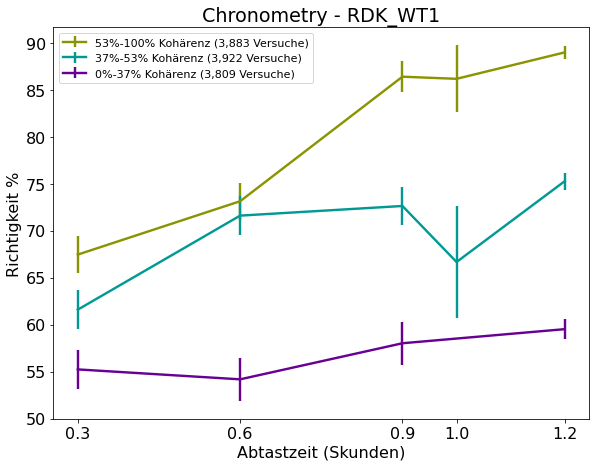

Bad performance (55.93%) for 2019-10-15-Sess1 - Len: 148
Bad performance (71.88%) for 2019-10-22-Sess1 - Len: 247
Bad performance (64.00%) for 2019-10-24-Sess1 - Len: 156
Bad performance (68.67%) for 2019-10-25-Sess2 - Len: 243
Bad performance (66.67%) for 2019-10-29-Sess1 - Len: 233
Bad performance (72.15%) for 2019-11-18-Sess1 - Len: 218
Bad performance (69.30%) for 2019-11-28-Sess1 - Len: 338
Insufficient trials (6) for 2019-12-12-Sess1
Bad performance (59.02%) for 2019-12-16-Sess1 - Len: 203
Bad performance (66.67%) for 2019-12-17-Sess1 - Len: 62
Subjext: RDK_WT4 - Chrone data max trial: [268 224 154 337 219 334 415 345 320 265 259 283 247 134 329 327 335 240
 312 294 323 282 258 315 342 297 326 267 422 350 464]
Min sampling points: [0.3, 0.6, 0.8999999999999999, 1.2, 1.5]
α: 0.4215080008461033 - β: 0.18305554616007963 - λ1: 0.5640278951777589 - λ2: 0.15925636298643991


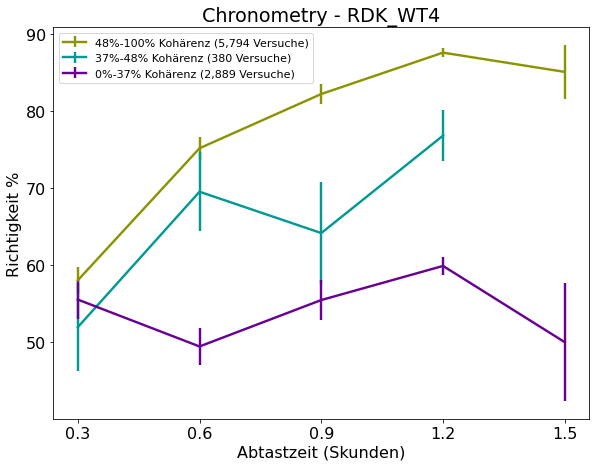

Bad performance (74.47%) for 2020-02-11-Sess1 - Len: 266
Insufficient trials (26) for 2020-02-12-Sess1
Bad performance (63.64%) for 2020-02-17-Sess1 - Len: 175
Bad performance (67.19%) for 2020-02-18-Sess1 - Len: 149
Bad performance (70.00%) for 2020-02-20-Sess1 - Len: 82
Insufficient trials (20) for 2020-02-24-Sess2
Bad performance (71.19%) for 2020-02-25-Sess1 - Len: 295
Bad performance (71.03%) for 2020-02-28-Sess1 - Len: 282
Insufficient trials (7) for 2020-03-02-Sess1
Bad performance (56.60%) for 2020-03-03-Sess1 - Len: 138
Bad performance (54.10%) for 2020-03-04-Sess1 - Len: 158
Bad performance (66.67%) for 2020-03-06-Sess1 - Len: 121
Bad performance (45.95%) for 2020-03-09-Sess1 - Len: 58
Subjext: WTS3 - Chrone data max trial: [368 397 303 363 367 256  76]
Min sampling points: [0.3, 1.2]
α: 0.7858944502425045 - β: 0.4099929057046321 - λ1: 0.5901444908969761 - λ2: 0.11436981836732125


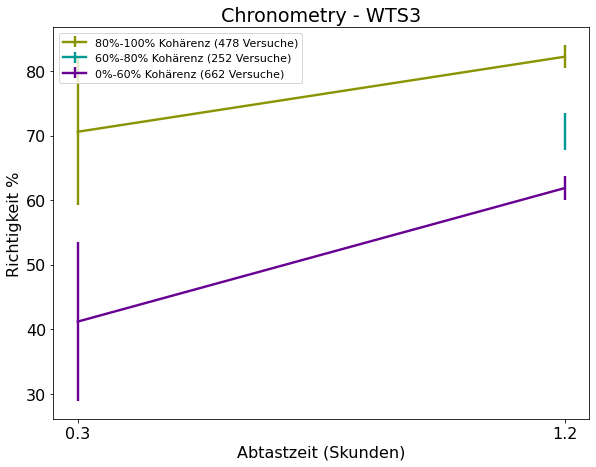

Insufficient trials (44) for 2020-02-10-Sess1
Bad performance (73.79%) for 2020-02-21-Sess1 - Len: 416
Bad performance (71.43%) for 2020-02-24-Sess2 - Len: 130
Bad performance (74.77%) for 2020-02-28-Sess1 - Len: 357
Bad performance (71.79%) for 2020-03-10-Sess2 - Len: 330
Insufficient trials (7) for 2020-03-10-Sess3
Bad performance (71.84%) for 2020-03-11-Sess2 - Len: 300
Insufficient trials (9) for 2020-03-11-Sess3
Subjext: rbp1 - Chrone data max trial: [390 222 283 327 417 346 365 312 432 419 342 367 325 396 454 145 253 430
 289 304]
Min sampling points: [0.3, 0.6, 0.8999999999999999, 1.2]
α: 0.35233064905344713 - β: 0.37227879263010855 - λ1: 0.5034899716309174 - λ2: 0.1837429658027952


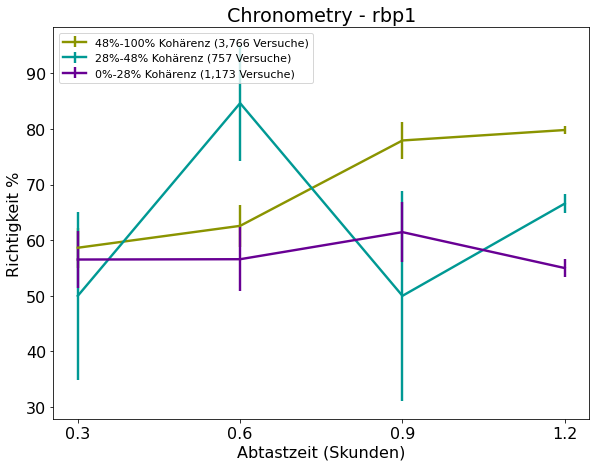

In [30]:
def run(df):
  from report import analysis
  analysis.setMatplotlibParams(silent=True)
  from report.evdaccum.chronometry import chronometry, Plots, AllPlots, NoPlots
  from report.evdaccum.evdutils import Kargs, GroupBy
  from report.definitions import ExpType
  vs_diff_kargs = Kargs(min_easiest_perf=75, save_figs=False,
                        exp_type=ExpType.RDK, grpby=GroupBy.Performance,
                        fitkargs={},
                        save_prefix="proto/Chronometry/")
  chronometry(df, plots=Plots.Chronometry, **vs_diff_kargs)
run(raw_df)

Loading Chronometry data...
Subjext: Chronometry - Chrone data max trial: [500.]
Min sampling points: [0.25, 0.5, 0.75, 1.0]
α: -0.062209966242189677 - β: 0.41936664269345925 - λ1: 0.15180796140554484 - λ2: 6.059888003919334e-10


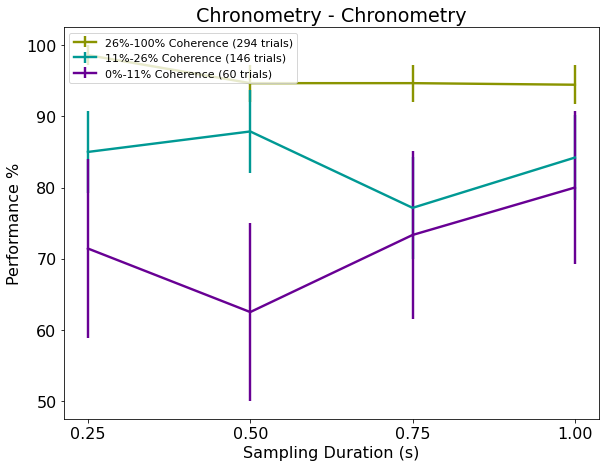

α: -0.0660619033506323 - β: 0.25553346034337826 - λ1: 0.006881855951616267 - λ2: 0.02948298999274087


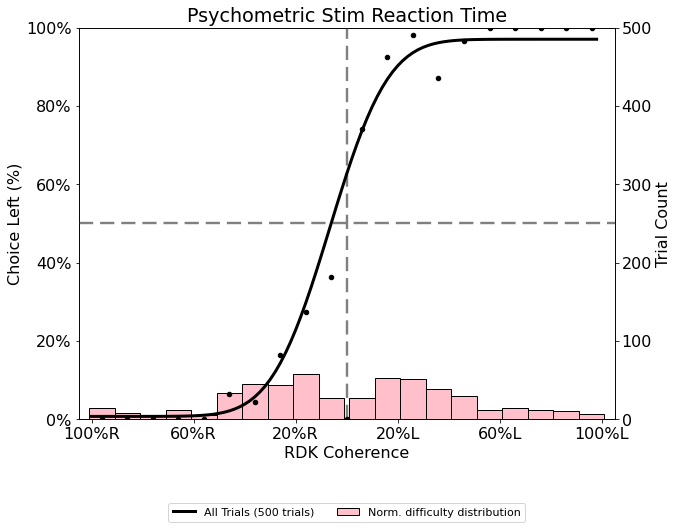

In [26]:
#@title Run this cell as well
def chrono(df):
  analysis.setMatplotlibParams(silent=True)
  df["GUI_StimAfterPokeOut"] = False
  df["GUI_MouseState"] = 2
  df["GUI_RewardAfterMinSampling"] = False
  df["GUI_MinSampleType"] = 4
  df["CenterPortRewAmount"] = 0
  df["GUI_MinSampleMax"] = 0.1
  df["GUI_StimulusTime"] = 0 # Seconds, otherwise overstay
  df["Difficulty1"] = df.DV.abs() * 100
  df["Difficulty3"] = 0
  df["ST"] = 0
  #df = df[df.DV.abs() < 0.4]
  from report.definitions import ExpType
  df["GUI_ExperimentType"] = ExpType.RDK
  from report.evdaccum.chronometry import chronometry, Plots, AllPlots, NoPlots
  from report.evdaccum.evdutils import Kargs, GroupBy
  from report.definitions import ExpType
  vs_diff_kargs = Kargs(min_easiest_perf=75, save_figs=False,
                        exp_type=ExpType.RDK, fitkargs={"nfits":50},
                        grpby=GroupBy.Performance,
                        #plot_only_all=False, periods=3,
                        save_prefix="proto/Chronometry/")
  chronometry(df, plots=Plots.Chronometry, **vs_diff_kargs)

def runChronometry():
#   if "uploaded" not in locals():
#     from google.colab import files
#     uploaded = files.upload()
  if len(uploaded):
    user_df = loadFiles(uploaded)
    chrono(user_df)
    psych(user_df)

runChronometry()

Loading Chronometry data...
α: -0.06607994536704656 - β: 0.25549574595842506 - λ1: 0.006859333208091124 - λ2: 0.02948618707192095
Period 1/3 dv = [0.74099022]
Cut off left: [0.41977209]
Period 2/3 dv = [0.85575201]
Cut off left: [0.21331577]
Closest dvs are:  [-1.01, -0.20999999999999996, -0.09999999999999998, 0, 0.06000000000000005, 0.15000000000000013, 1.01] at perfms: [0.21195884537708576, 0.41692801721155304, 0.7367044098231637, 0.8588836624573754] with min. perf: [0.62622842] and max perf L/R: 0.0068594463572622544 0.9705138111865658
α: -0.06606515738158827 - β: 0.2555565413229028 - λ1: 0.006841134810047566 - λ2: 0.02946867953692662


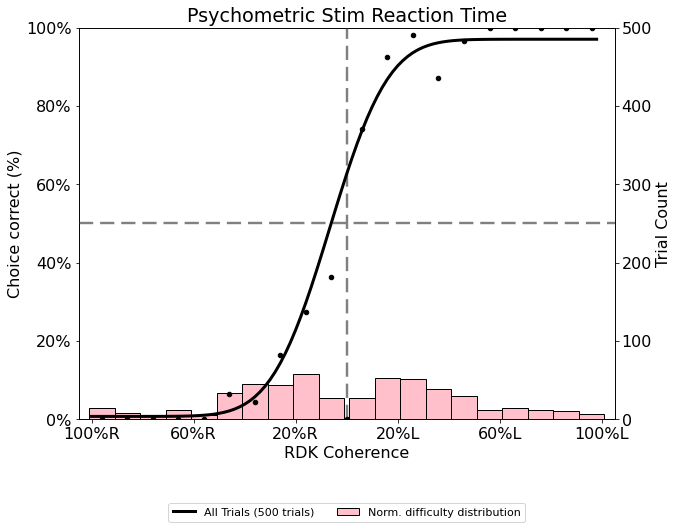

In [73]:
def test():
    from report.evdaccum.evdutils import rngByPerf
    user_df = loadFiles(uploaded)
    rngByPerf(user_df, periods=3, fit_fn_periods=10, combine_sides=False, separate_zero=False)
    psych(user_df)

test()

In [66]:
def test2():
    fp = r"C:\Users\hatem\Downloads\ReactionTime (3).csv"
    with open(fp, 'r') as f:
        txt = f.read()
    x = txt.replace('"','').replace("Taste, um", "Taste um").replace("Tastaturtaste, die", "Tastaturtaste die")
    x = x.replace("Tastatur, die", "Tastatur die")
    print()
    new_fp = fp[:-4] +"_new.csv"
    with open(new_fp, 'w') as f:
        f.write(x)
    import pandas as pd
    df = pd.read_csv(new_fp)
    #df = df[df.TrialNumber.notnull()]
    if (df.Experiment == "Chronometry").any():
        valid_trials = df[df.TrialNumber.notnull()]
        df.loc[valid_trials.index - 1, "TrialNumber"] = valid_trials.TrialNumber.values
        df.loc[valid_trials.index - 1, "Difficulty"] = valid_trials.Difficulty.values
        df.loc[valid_trials.index - 1, "Direction"] = valid_trials.Direction.values
        df.loc[valid_trials.index - 1, "Experiment"] = valid_trials.Experiment.values
        #display(df.TrialNumber)
        #display("df len:", df.loc[valid_trials.index - 1, "TrialNumber"])
        df.to_csv(new_fp)


def test():
    fp = r"C:\Users\hatem\Downloads\ReactionTime (3).csv"
    with open(fp, 'r') as f:
        lines = f.readlines()
    res = []
    for line in lines:
        first_comma = line.index(",")
        line = line[:first_comma] + '",' + line[first_comma+2:]
        #line = line.replace('""', ':'
        #line = line.replace(r'""""','_TEMP4_').replace(r'"""', "_TEMP3_").replace(r'""','"')
        #line = line.replace("_TEMP4_",r'""').replace("_TEMP3_",r'""')
        if ';;;' in line:
            n_lines = line.split(';;;')
        else:
            n_lines = [line]
        res += n_lines
    #x = txt.replace('"','').replace("Taste, um", "Taste um").replace("Tastaturtaste, die", "Tastaturtaste die")
    #x = x.replace("Tastatur, die", "Tastatur die")
    #print()
    new_fp = fp[:-4] +"_new.csv"
    with open(new_fp, 'w') as f:
        f.writelines(res)
    import pandas as pd
    df = pd.read_csv(new_fp)
    #df = df[df.TrialNumber.notnull()]
    if (df.Experiment == "Chronometry").any():
        valid_trials = df[df.TrialNumber.notnull()]
        df.loc[valid_trials.index - 1, "TrialNumber"] = valid_trials.TrialNumber.values
        df.loc[valid_trials.index - 1, "Difficulty"] = valid_trials.Difficulty.values
        df.loc[valid_trials.index - 1, "Direction"] = valid_trials.Direction.values
        df.loc[valid_trials.index - 1, "Experiment"] = valid_trials.Experiment.values
        #display(df.TrialNumber)
        #display("df len:", df.loc[valid_trials.index - 1, "TrialNumber"])
        df.to_csv(new_fp)

test()

ParserError: Error tokenizing data. C error: Expected 2 fields in line 3, saw 100
